### Subgraph

A subgraph is essentially a graph that functions as a node within another graph. Subgraphs are particularly useful for:

* Building multi-agent systems
* Reusing a set of nodes across multiple graphs
* Distributing development: When different teams are working on separate parts of a graph, each part can be defined as a subgraph. As long as the subgraph's input and output interfaces are adhered to, the parent graph can be constructed without needing to know the specifics of the subgraph.

When incorporating subgraphs, it's important to define how the parent graph and subgraph will interact:

* **Invoke a graph from a node**: Subgraphs are called within a node of the parent graph.
* **Add a graph as a node**: A subgraph is added directly as a node in the parent graph and shares state keys with it.


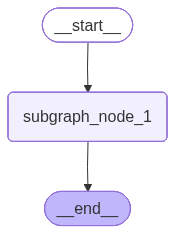

In [1]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START
# --- Subgraph definition ---

class SubgraphState(TypedDict):
    greet: str
    
def subgraph_node_1(state: SubgraphState):
    return {"greet": "Hi! " + state["greet"]}
subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node("subgraph_node_1", subgraph_node_1)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph = subgraph_builder.compile()
subgraph

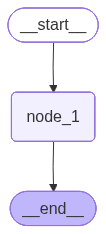

In [2]:
# --- Parent graph definition ---
class State(TypedDict):
    player: str
    
def call_subgraph(state: State):
    
    subgraph_output = subgraph.invoke({"greet": state["player"]})
    
    return {"player": subgraph_output["greet"]}
    
builder = StateGraph(State)
builder.add_node("node_1", call_subgraph)
builder.add_edge(START, "node_1")
graph = builder.compile()

graph



In [3]:
# --- Run the graph ---
input_state = {"player": "Virat"}
output_state = graph.invoke(input_state)
print("Input:", input_state)
print("Output:", output_state)

Input: {'player': 'Virat'}
Output: {'player': 'Hi! Virat'}


In [4]:
for chunk in graph.stream(input_state):
    print(chunk)

{'node_1': {'player': 'Hi! Virat'}}


# Example 2

#### Mutli-agent Grader with SubGraphs

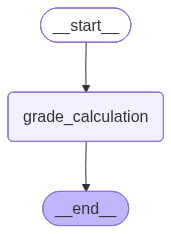

In [5]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START

# --- Subgraph definition ---

class GradeState(TypedDict):
    marks: int
    grade:str
    
def grade_calculation(state: GradeState):
    marks = state["marks"]
    if marks >= 90:
        return {"grade": "A"}
    elif marks >= 80:
        return {"grade": "B"}
    elif marks >= 65:
        return {"grade": "C"}
    elif marks >= 50:
        return {"grade": "D"}
    else:
        return {"grade": "F"}

subgraph_builder = StateGraph(GradeState)
subgraph_builder.add_node("grade_calculation", grade_calculation)
subgraph_builder.add_edge(START, "grade_calculation")
grade_subgraph = subgraph_builder.compile()
grade_subgraph


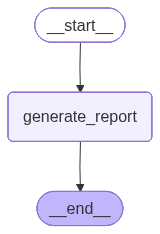

In [6]:
# --- Parent graph definition ---

class StudentState(TypedDict):
    name: str
    grade:str
    report:str
    marks:int
    
def generate_report(state: StudentState):
    # Call the grade subgraph with the student's marks
    grade_output = grade_subgraph.invoke({"marks": state["marks"]})
    
    grade = grade_output["grade"]
    
    
    # Generate a performance report based on the grade
    report = f"{state['name']} received a grade of {grade}."
    
    # Return the complete state with name, grade, and report
    return {"grade": grade, "report": report}
    

builder = StateGraph(StudentState)
builder.add_node("generate_report", generate_report)
builder.add_edge(START, "generate_report")
performance_report_graph = builder.compile()
performance_report_graph


In [7]:
# Sample invocation
student_state = {"name": "Raj", "marks": 65}
report = performance_report_graph.invoke(student_state)
print(report)


{'name': 'Raj', 'grade': 'C', 'report': 'Raj received a grade of C.', 'marks': 65}
